# Comprehensive OpenCV Assignment

Follow the instructions in each section and write your code in the provided empty cells using the specified file names.

## 2. Drawing and Text
**Task:**
1. Create a blank image of size $500 \times 500$ with 3 color channels.
2. Paint a portion of the image red ($[200:300, 300:400]$).
3. Draw a green rectangle from $(0,0)$ to the center of the image.
4. Draw a red circle at the center with a radius of 40.
5. Draw a white line from $(100, 250)$ to $(300, 400)$.



Matplotlib is building the font cache; this may take a moment.


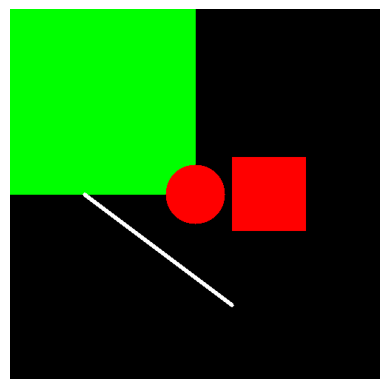

In [2]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

blank = np.zeros((500, 500, 3), dtype='uint8')

blank[200:300, 300:400] = 0, 0, 255
cv.rectangle(blank, (0, 0), (250, 250), (0, 255, 0), thickness=-1)
cv.circle(blank, (250, 250), 40, (0, 0, 255), thickness=-1)
cv.line(blank, (100, 250), (300, 400), (255, 255, 255), thickness=3)

rgb_blank = cv.cvtColor(blank, cv.COLOR_BGR2RGB)

plt.imshow(rgb_blank)
plt.axis('off')
plt.show()

## 3. Basic Image Functions
**Task:**
1. Load `park.jpg`.
2. Convert it to grayscale.
3. Apply Gaussian Blur with a $(7,7)$ kernel.
4. Perform Canny Edge detection on the blurred image.


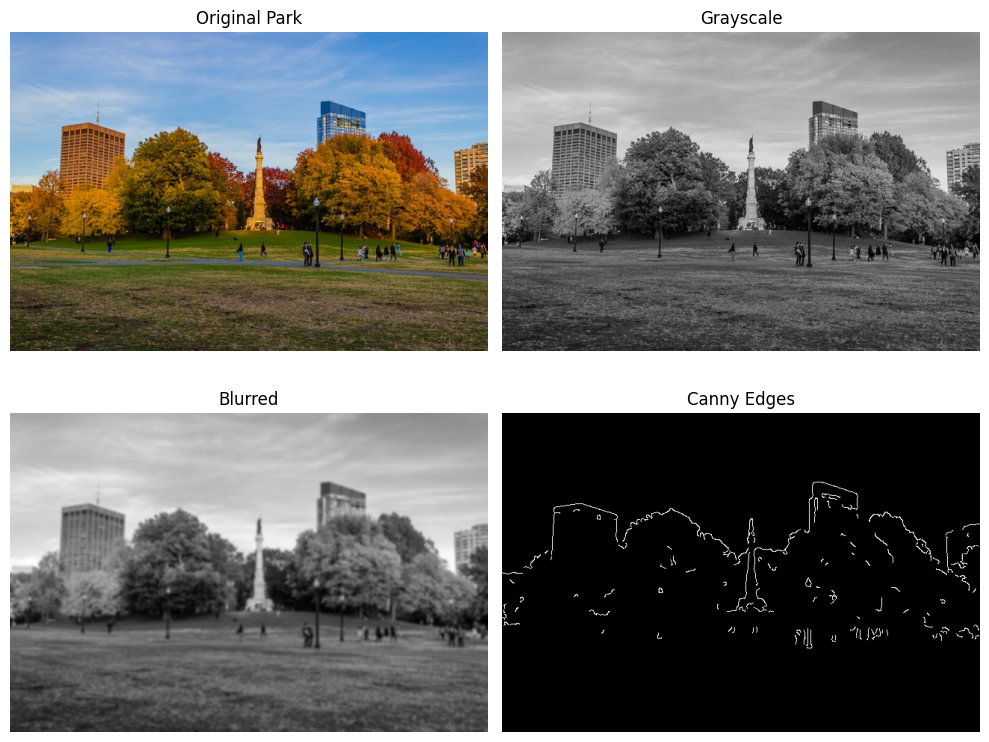

In [4]:
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread('park.jpg')

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
blur = cv.GaussianBlur(gray, (7, 7), 0)
canny = cv.Canny(blur, 125, 175)

rgb_img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(rgb_img)
plt.title('Original Park')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(blur, cmap='gray')
plt.title('Blurred')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(canny, cmap='gray')
plt.title('Canny Edges')
plt.axis('off')

plt.tight_layout()
plt.show()

## 4. Image Transformations
**Task:**
1. Create a function `translate(img, x, y)` to shift an image.
2. Create a function `rotate(img, angle, rotPoint=None)` to rotate an image.
3. Apply a flip transformation to `park.jpg`.

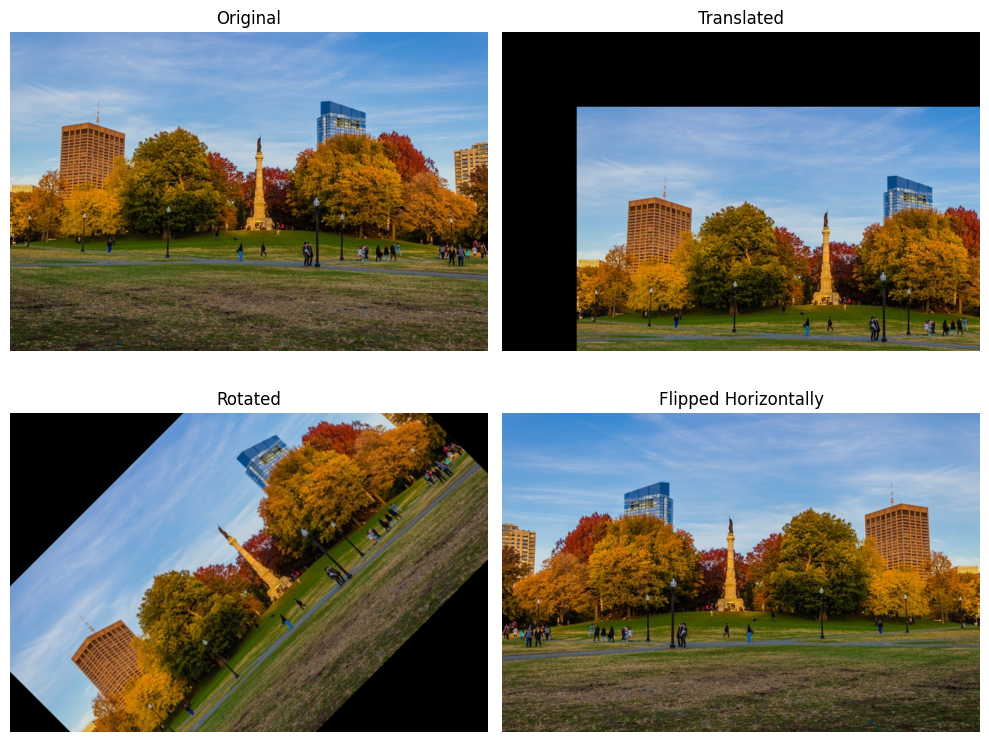

In [5]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('park.jpg')

def translate(img, x, y):
    transMat = np.float32([[1, 0, x], [0, 1, y]])
    dimensions = (img.shape[1], img.shape[0]) 
    return cv.warpAffine(img, transMat, dimensions)

def rotate(img, angle, rotPoint=None):
    (height, width) = img.shape[:2]
    
    if rotPoint is None:
        rotPoint = (width // 2, height // 2)
    rotMat = cv.getRotationMatrix2D(rotPoint, angle, 1.0)
    dimensions = (width, height)
    
    return cv.warpAffine(img, rotMat, dimensions)

translated_img = translate(img, 100, 100)
rotated_img = rotate(img, 45)
flipped_img = cv.flip(img, 1)

rgb_img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
rgb_translated = cv.cvtColor(translated_img, cv.COLOR_BGR2RGB)
rgb_rotated = cv.cvtColor(rotated_img, cv.COLOR_BGR2RGB)
rgb_flipped = cv.cvtColor(flipped_img, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(rgb_img)
plt.title('Original')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(rgb_translated)
plt.title('Translated')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(rgb_rotated)
plt.title('Rotated')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(rgb_flipped)
plt.title('Flipped Horizontally')
plt.axis('off')

plt.tight_layout()
plt.show()

## 5. Contour Detection
**Task:**
1. Load `cats.jpg`.
2. Convert to grayscale and apply Gaussian blur.
3. Find the edges using Canny.
4. Use `cv.findContours` to find all contours.
5. Print the count and draw them on a blank image.

141 contour(s) found!


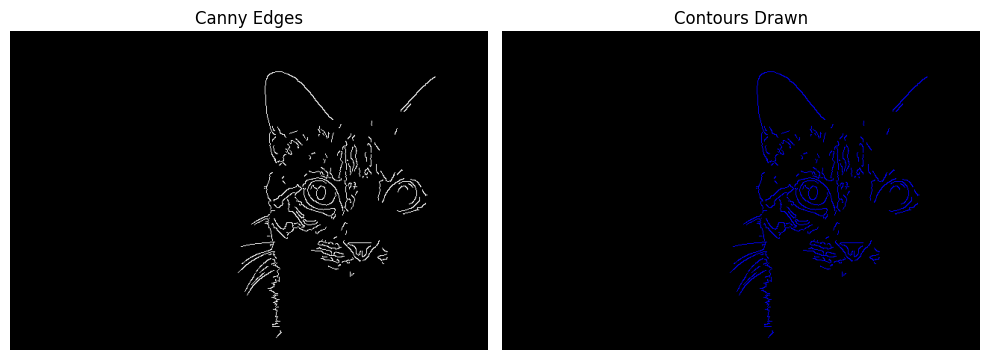

In [6]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('cat.jpg')

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
blur = cv.GaussianBlur(gray, (5, 5), 0)
canny = cv.Canny(blur, 125, 175)

contours, hierarchies = cv.findContours(canny, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)
print(f'{len(contours)} contour(s) found!')
blank = np.zeros(img.shape, dtype='uint8')

cv.drawContours(blank, contours, -1, (255, 0, 0), 1)

rgb_blank = cv.cvtColor(blank, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(canny, cmap='gray')
plt.title('Canny Edges')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rgb_blank)
plt.title('Contours Drawn')
plt.axis('off')

plt.tight_layout()
plt.show()

## 6. Color Spaces
**Task:**
1. Load `park.jpg`.
2. Convert and display in: Gray, HSV,and RGB.

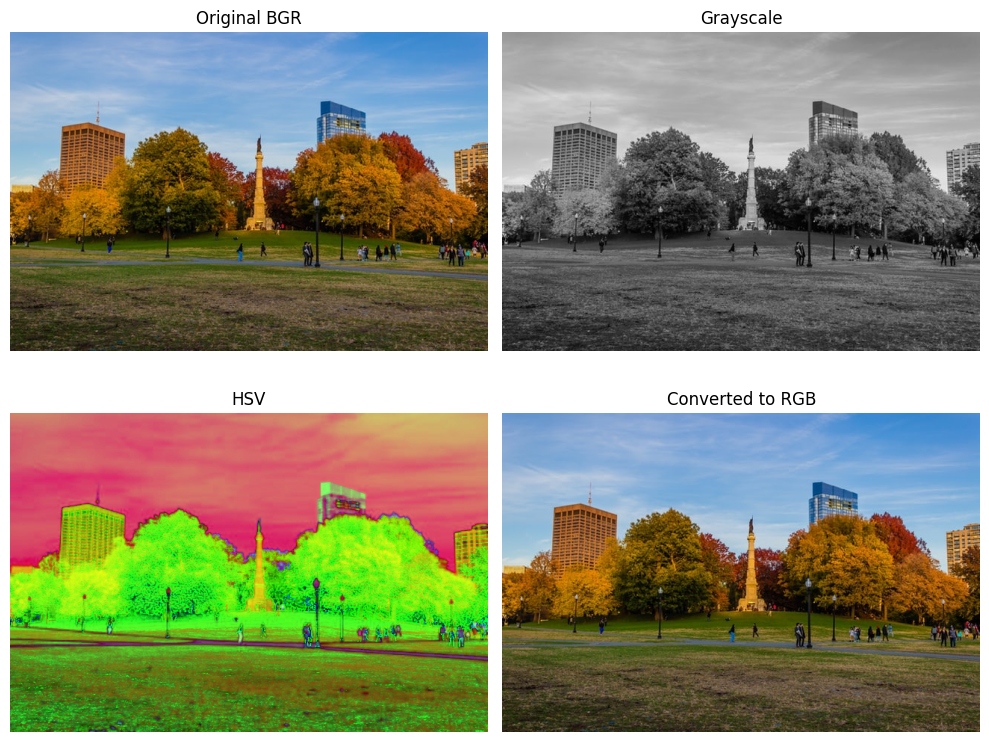

In [7]:
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread('park.jpg')

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB) 

rgb_img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
rgb_hsv = cv.cvtColor(hsv, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(rgb_img)
plt.title('Original BGR')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(rgb_hsv)
plt.title('HSV')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(rgb)
plt.title('Converted to RGB')
plt.axis('off')

plt.tight_layout()
plt.show()

## 7. Smoothing and Blurring
**Task:**
1. Load `cats.jpg`.
2. Apply Averaging, Gaussian and Median Blurs

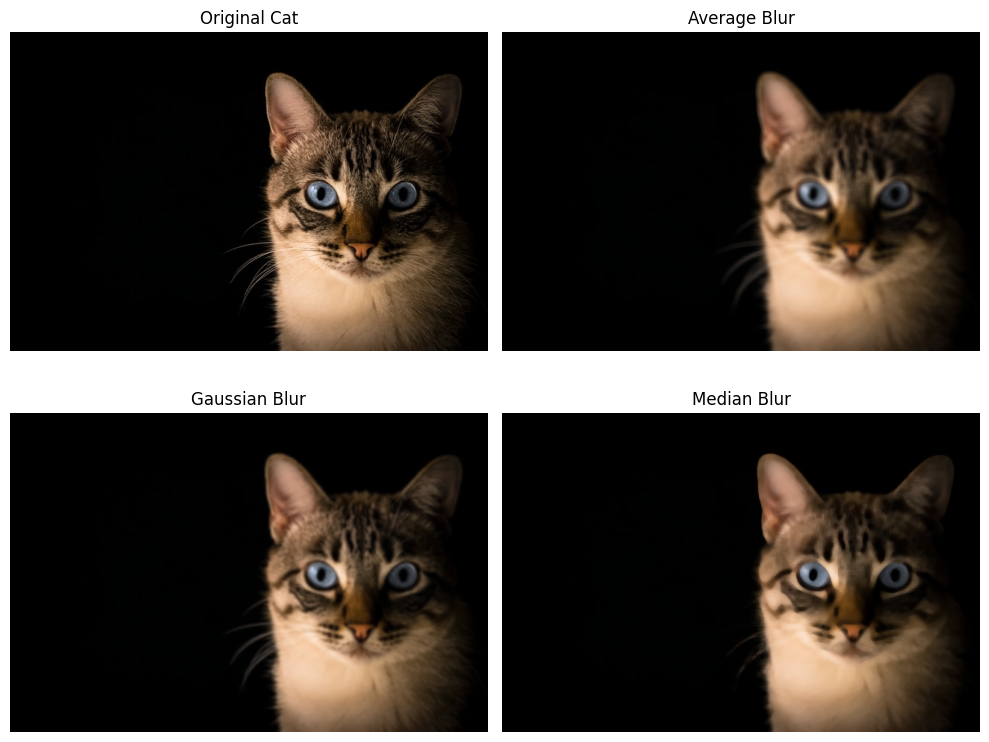

In [8]:
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread('cat.jpg')

average = cv.blur(img, (7, 7))
gauss = cv.GaussianBlur(img, (7, 7), 0)
median = cv.medianBlur(img, 7)

rgb_img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
rgb_average = cv.cvtColor(average, cv.COLOR_BGR2RGB)
rgb_gauss = cv.cvtColor(gauss, cv.COLOR_BGR2RGB)
rgb_median = cv.cvtColor(median, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(rgb_img)
plt.title('Original Cat')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(rgb_average)
plt.title('Average Blur')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(rgb_gauss)
plt.title('Gaussian Blur')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(rgb_median)
plt.title('Median Blur')
plt.axis('off')

plt.tight_layout()
plt.show()

## 8. Bitwise Operations
**Task:**
1. Create a $400 \times 400$ blank image.
2. Create a rectangle and a circle on separate blank images.
3. Perform Bitwise AND, OR, XOR, and NOT.

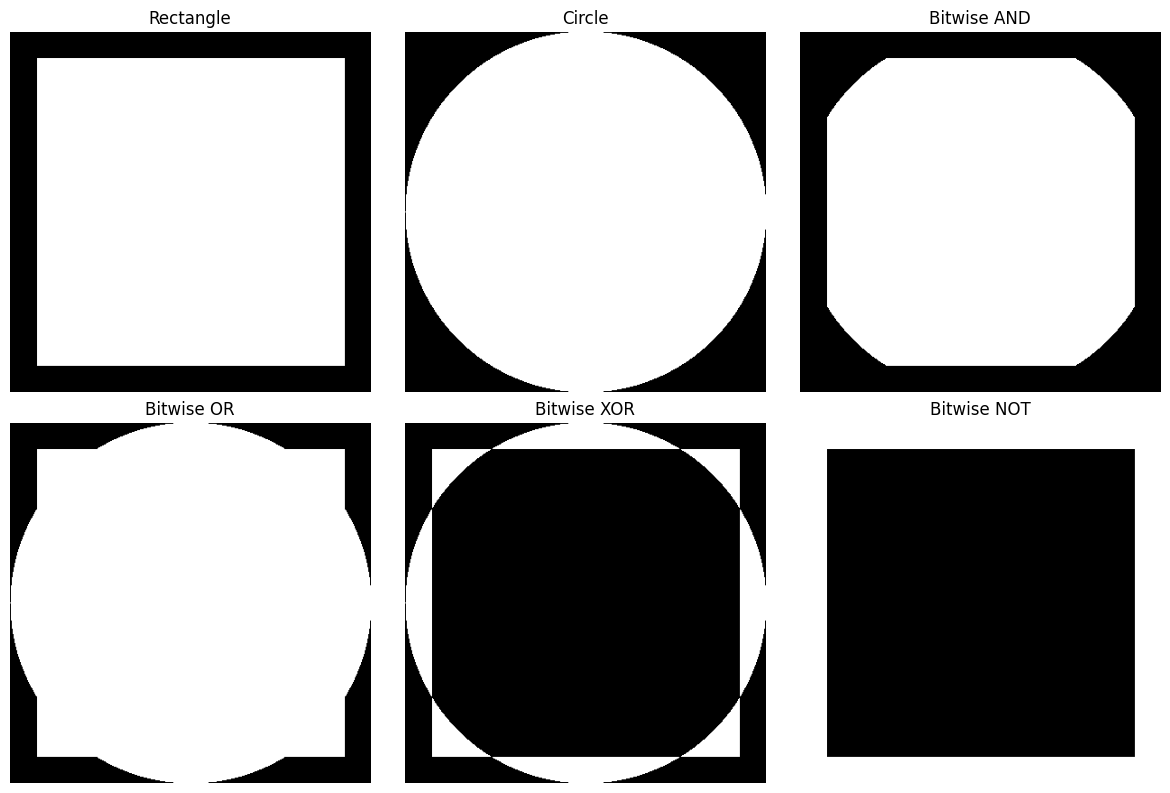

In [9]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

blank = np.zeros((400, 400), dtype='uint8')

rectangle = cv.rectangle(blank.copy(), (30, 30), (370, 370), 255, -1)
circle = cv.circle(blank.copy(), (200, 200), 200, 255, -1)

bitwise_and = cv.bitwise_and(rectangle, circle)
bitwise_or = cv.bitwise_or(rectangle, circle)
bitwise_xor = cv.bitwise_xor(rectangle, circle)
bitwise_not = cv.bitwise_not(rectangle)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(rectangle, cmap='gray')
plt.title('Rectangle')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(circle, cmap='gray')
plt.title('Circle')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(bitwise_and, cmap='gray')
plt.title('Bitwise AND')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(bitwise_or, cmap='gray')
plt.title('Bitwise OR')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(bitwise_xor, cmap='gray')
plt.title('Bitwise XOR')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(bitwise_not, cmap='gray')
plt.title('Bitwise NOT')
plt.axis('off')

plt.tight_layout()
plt.show()

## 9. Thresholding
**Task:**
1. Load `cats.jpg` and convert to grayscale.
2. Apply Simple Thresholding (Binary and Inverse).

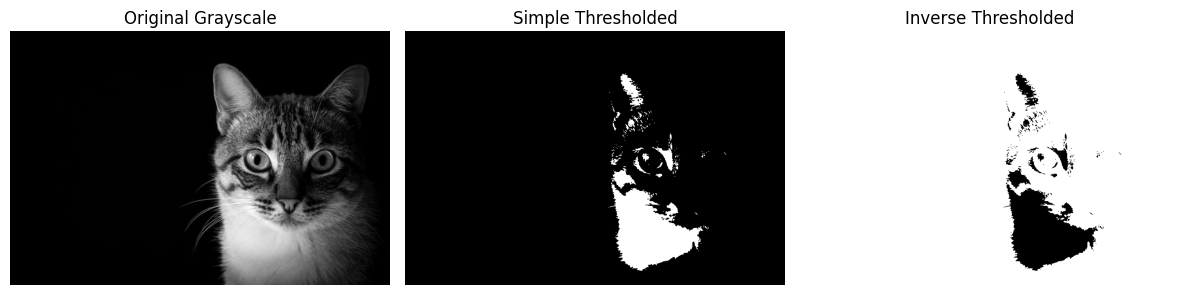

In [10]:
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread('cat.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

threshold_val, thresh = cv.threshold(gray, 150, 255, cv.THRESH_BINARY)
threshold_val_inv, thresh_inv = cv.threshold(gray, 150, 255, cv.THRESH_BINARY_INV)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original Grayscale')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(thresh, cmap='gray')
plt.title('Simple Thresholded')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(thresh_inv, cmap='gray')
plt.title('Inverse Thresholded')
plt.axis('off')

plt.tight_layout()
plt.show()